# Ligue 1: The PSG Effect
**French football before and after the Qatari takeover**

*Eric Schnitger, 2026*

---

## Key Findings

- Pre-PSG: **8 different champions** in 20 seasons
- Post-PSG: PSG have won ~10 of 13 titles
- **Montpellier (2012)**, **Monaco (2017)**, **Lille (2021)** are remarkable upsets
       

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from _utils import (
   LEAGUES, scrape_league, enrich_dataframe,
   build_league_chart, build_comparison_chart, build_frequency_tables,
)
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [3]:
config = LEAGUES["ligue_1"]
df = scrape_league("ligue_1", cache_dir="../data")
df = enrich_dataframe(df)
print(f"Loaded {len(df)} seasons")
df.tail(10)

  [L1] cache hit (0.0d old)
Loaded 31 seasons


,Season,Start Year,Num Teams,Matches,Champion,Title-Winning Points,2nd Place,2nd Place Points,3rd Place,3rd Place Points,...,Relegated 2,Relegated 3,Gap,Ratio,Title PPG,Survival PPG,Gap PPG,Title Pts (38-game),Survival Pts (38-game),Gap (38-game)
21,2014/15,2014,20,38,Paris Saint-Germain,83,Lyon,75,Monaco,71,...,Metz,Lens,41,1.98,2.184,1.105,1.079,83.0,42.0,41.0
22,2015/16,2015,20,38,Paris Saint-Germain,96,Monaco,65,Lyon,65,...,Gazélec Ajaccio,Troyes,56,2.40,2.526,1.053,1.473,96.0,40.0,56.0
23,2016/17,2016,20,38,Monaco,95,Paris Saint-Germain,87,Nice,78,...,Nancy,Bastia,58,2.57,2.500,0.974,1.526,95.0,37.0,58.0
24,2017/18,2017,20,38,Paris Saint-Germain,93,Monaco,80,Lyon,78,...,Troyes,Metz,55,2.45,2.447,1.000,1.447,93.0,38.0,55.0
25,2018/19,2018,20,38,Paris Saint-Germain,91,Lille,75,Lyon,72,...,Caen,Guingamp,55,2.53,2.395,0.947,1.448,91.0,36.0,55.0
26,2019/20,2019,20,38,Paris Saint-Germain,68,Marseille,56,Rennes,50,...,Amiens,Toulouse,38,2.27,1.789,0.789,1.000,68.0,30.0,38.0
27,2020/21,2020,20,38,Lille,83,Paris Saint-Germain,82,Monaco,78,...,Nîmes,Dijon,42,2.02,2.184,1.079,1.105,83.0,41.0,42.0
28,2022/23,2022,20,38,Paris Saint-Germain,85,Lens,84,Marseille,73,...,Troyes,Angers,50,2.43,2.237,0.921,1.316,85.0,35.0,50.0
29,2023/24,2023,18,34,Paris Saint-Germain,76,Monaco,67,Brest,61,...,Lorient,Clermont,44,2.38,2.235,0.941,1.294,84.9,35.8,49.2
30,2024/25,2024,18,34,Paris Saint-Germain,84,Marseille,65,Monaco,61,...,Saint-Étienne,Montpellier,50,2.47,2.471,1.000,1.471,93.9,38.0,55.9


## Interactive Analysis

In [4]:
eras = [
   {"label": "Full History (1992-2025)",
    "start": df["Season"].iloc[0], "end": df["Season"].iloc[-1],
    "title": "Ligue 1: The PSG Effect (1992-2025)"},
   {"label": "Open Era (1992-2002)",
    "start": "1992/93", "end": "2001/02",
    "title": "Ligue 1: The Open Era"},
   {"label": "Lyon Dynasty (2002-2008)",
    "start": "2002/03", "end": "2007/08",
    "title": "Ligue 1: Lyon's Seven Titles"},
   {"label": "PSG Era (2011-2025)",
    "start": "2011/12", "end": df["Season"].iloc[-1],
    "title": "Ligue 1: The PSG Era"},
]

notable = [
   ("2011/12", "Montpellier!",  "#66FF66", -50, -30),
   ("2015/16", "PSG dominant",  "#4FC3F7",   0, -25),
   ("2020/21", "Lille upset",   "#FFD54F", -50, -30),
]
outliers = []
for season, text, color, ax, ay in notable:
   match = df[df["Season"] == season]
   if not match.empty:
       outliers.append({
           "season": season,
           "y": int(match["Title-Winning Points"].iloc[0]),
           "text": text, "color": color, "ax": ax, "ay": ay,
       })

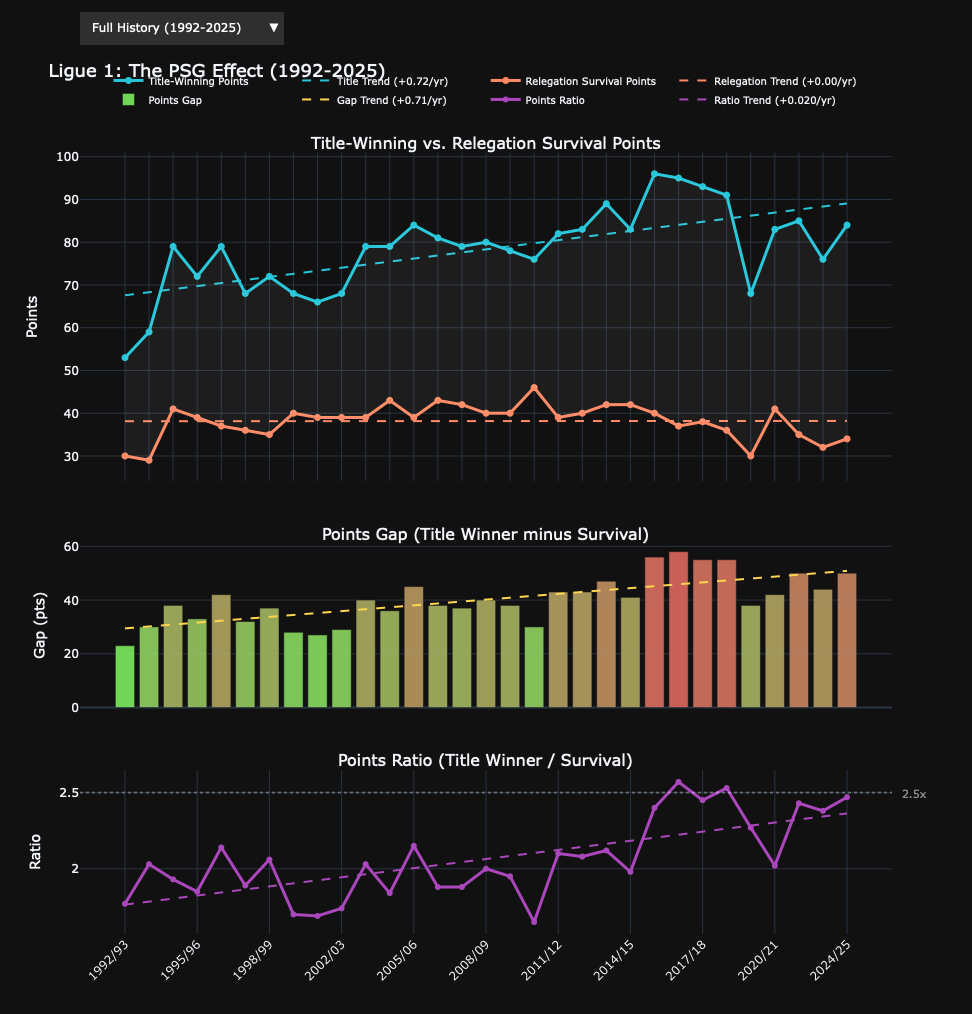

In [5]:
fig = build_league_chart(df, config, eras=eras, outliers=outliers)
fig

## Top 4 Concentration

In [6]:
top4, relegated = build_frequency_tables(df, config)
top4.head(10).style.format({"Percentage": "{:.1f}%"}).hide(axis="index")

Club,Top 4 Finishes,Percentage
Paris Saint-Germain,21,67.7%
Lyon,21,67.7%
Marseille,16,51.6%
Monaco,16,51.6%
Lille,11,35.5%
Bordeaux,9,29.0%
Auxerre,6,19.4%
Lens,4,12.9%
Nice,4,12.9%
Rennes,4,12.9%


## Relegated Clubs

In [7]:
relegated.head(10).style.hide(axis="index")

Club,Times Relegated
Troyes,6
Metz,6
Toulouse,5
Caen,5
Saint-Étienne,4
Guingamp,4
Lorient,4
Nancy,3
Ajaccio,3
Lens,3
